In [1]:
import numpy as np
import pandas as pd
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

In [2]:
def load_results(path):
    df = pd.read_csv(path)

    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    for col in df.columns:
        if col.endswith("_all"):
            df[col] = (
                df[col]
                .str.replace('[', '')
                .str.replace(']', '')
                .apply(lambda x: [float(v) for v in x.split()])
            )
    return df

def to_long(df, representation, metric="F1_macro"):
    rows = []

    for _, row in df.iterrows():
        model = row["Model"]
        scores = row[f"CV_{metric}_all"]

        for s in scores:
            rows.append({
                "Representation": representation,
                "Model": model,
                metric: s
            })

    return pd.DataFrame(rows)

## TweetEmotionsPTBR

In [16]:
paths = {
    "BoW": "../../data/out/baseline/baseline_03_TweetEmotionsPTBR_BoW.csv",
    "TFIDF": "../../data/out/baseline/baseline_03_TweetEmotionsPTBR_TFIDF.csv",
}

df_bow = load_results(paths["BoW"])
df_tfidf = load_results(paths["TFIDF"])

df_long = pd.concat([
    to_long(df_bow, "BoW"),
    to_long(df_tfidf, "TFIDF")
], ignore_index=True)

df_pair = (
    df_long
    .groupby(["Representation"])
    .head(df_long.groupby("Representation").size().min())
    .reset_index(drop=True)
)

scores_bow = df_pair[df_pair["Representation"] == "BoW"]["F1_macro"].to_numpy()
scores_tfidf = df_pair[df_pair["Representation"] == "TFIDF"]["F1_macro"].to_numpy()

stat, p = wilcoxon(scores_bow, scores_tfidf)

print(f"Wilcoxon stat = {stat:.4f}")
print(f"p-value = {p:.6f}")

n = len(scores_bow)
mean_w = n * (n + 1) / 4
std_w = np.sqrt(n * (n + 1) * (2*n + 1) / 24)

z = (stat - mean_w) / std_w
r = abs(z) / np.sqrt(n)

print(f"Z = {z:.4f}")
print(f"Effect size (r) = {r:.4f}")

Wilcoxon stat = 4205.0000
p-value = 0.006245
Z = -2.7346
Effect size (r) = 0.2233


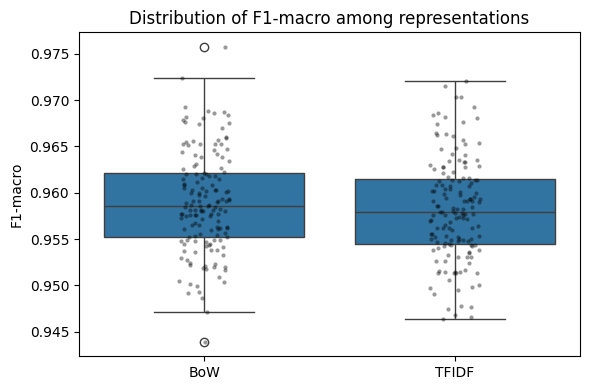

In [17]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_long,
    x="Representation",
    y="F1_macro"
)

sns.stripplot(
    data=df_long,
    x="Representation",
    y="F1_macro",
    color="black",
    alpha=0.4,
    size=3
)

plt.title("Distribution of F1-macro among representations")
plt.ylabel("F1-macro")
plt.xlabel("")
plt.tight_layout()
plt.show()

## GoEmotions

### EN

In [3]:
paths = {
    "BoW": "../../data/out/baseline/baseline_05_GoEmotions_BoW_EN.csv",
    "TFIDF": "../../data/out/baseline/baseline_05_GoEmotions_TFIDF_EN.csv",
}

df_bow = load_results(paths["BoW"])
df_tfidf = load_results(paths["TFIDF"])

df_long = pd.concat([
    to_long(df_bow, "BoW"),
    to_long(df_tfidf, "TFIDF")
], ignore_index=True)

df_pair = (
    df_long
    .groupby(["Representation"])
    .head(df_long.groupby("Representation").size().min())
    .reset_index(drop=True)
)

scores_bow = df_pair[df_pair["Representation"] == "BoW"]["F1_macro"].to_numpy()
scores_tfidf = df_pair[df_pair["Representation"] == "TFIDF"]["F1_macro"].to_numpy()

stat, p = wilcoxon(scores_bow, scores_tfidf)

print(f"Wilcoxon stat = {stat:.4f}")
print(f"p-value = {p:.6f}")

n = len(scores_bow)
mean_w = n * (n + 1) / 4
std_w = np.sqrt(n * (n + 1) * (2*n + 1) / 24)

z = (stat - mean_w) / std_w
r = abs(z) / np.sqrt(n)

print(f"Z = {z:.4f}")
print(f"Effect size (r) = {r:.4f}")

Wilcoxon stat = 136.0000
p-value = 0.000000
Z = -10.3690
Effect size (r) = 0.8466


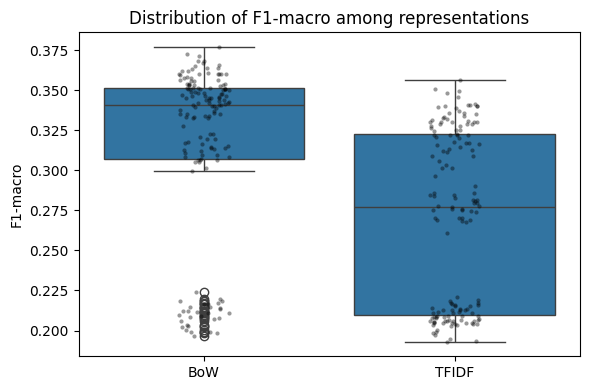

In [4]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_long,
    x="Representation",
    y="F1_macro"
)

sns.stripplot(
    data=df_long,
    x="Representation",
    y="F1_macro",
    color="black",
    alpha=0.4,
    size=3
)

plt.title("Distribution of F1-macro among representations")
plt.ylabel("F1-macro")
plt.xlabel("")
plt.tight_layout()
plt.show()

### PT

In [5]:
paths = {
    "BoW": "../../data/out/baseline/baseline_05_GoEmotions_BoW_PT.csv",
    "TFIDF": "../../data/out/baseline/baseline_05_GoEmotions_TFIDF_PT.csv",
}

df_bow = load_results(paths["BoW"])
df_tfidf = load_results(paths["TFIDF"])

df_long = pd.concat([
    to_long(df_bow, "BoW"),
    to_long(df_tfidf, "TFIDF")
], ignore_index=True)

df_pair = (
    df_long
    .groupby(["Representation"])
    .head(df_long.groupby("Representation").size().min())
    .reset_index(drop=True)
)

scores_bow = df_pair[df_pair["Representation"] == "BoW"]["F1_macro"].to_numpy()
scores_tfidf = df_pair[df_pair["Representation"] == "TFIDF"]["F1_macro"].to_numpy()

stat, p = wilcoxon(scores_bow, scores_tfidf)

print(f"Wilcoxon stat = {stat:.4f}")
print(f"p-value = {p:.6f}")

n = len(scores_bow)
mean_w = n * (n + 1) / 4
std_w = np.sqrt(n * (n + 1) * (2*n + 1) / 24)

z = (stat - mean_w) / std_w
r = abs(z) / np.sqrt(n)

print(f"Z = {z:.4f}")
print(f"Effect size (r) = {r:.4f}")

Wilcoxon stat = 104.0000
p-value = 0.000000
Z = -10.4291
Effect size (r) = 0.8515


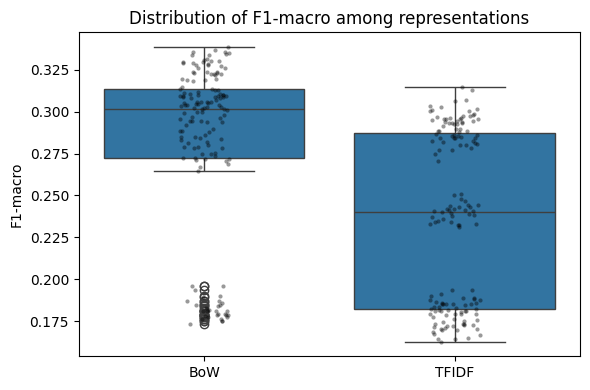

In [6]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_long,
    x="Representation",
    y="F1_macro"
)

sns.stripplot(
    data=df_long,
    x="Representation",
    y="F1_macro",
    color="black",
    alpha=0.4,
    size=3
)

plt.title("Distribution of F1-macro among representations")
plt.ylabel("F1-macro")
plt.xlabel("")
plt.tight_layout()
plt.show()